## Exploratory Data Analysis

In [18]:
# Import libraries
import pandas as pd
pd.set_option('display.max_columns', 100)

import numpy as np

# matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [22]:
# import dataset
df = pd.read_csv('./flights_cleaned_df.csv')
df.sample(5)

,origin,City,destination,City_destination,distance_km,Name_airline,aircraft,query_date,departure_date,departure_clock_time,day_of_week_departure,month_departure,arrival_date,arrival_clock_time,days_until_departure,trip_duration_minutes,number_of_stops,bookable_seats,base_price,total_price
42204,YYC,Calgary,YVR,Vancouver,686.261438,WestJet,73W,2026-03-08,2026-08-09,16:30:00,6,8,2026-08-09,19:30:00,154,132,1,9,204,273.17
38157,YYC,Calgary,YYZ,Toronto,2689.246727,WestJet,7M8,2026-03-08,2026-06-14,09:00:00,6,6,2026-06-14,14:52:00,98,232,0,7,74,127.39
17803,YOW,Ottawa,YVR,Vancouver,3552.042539,Air Canada,DH4,2026-03-08,2026-08-23,20:55:00,6,8,2026-08-24,09:50:00,168,371,1,9,215,300.49
28919,YVR,Vancouver,YOW,Ottawa,3552.042539,WestJet,7M8,2026-03-08,2026-10-25,16:30:00,6,10,2026-10-26,12:15:00,231,360,2,9,228,304.33
17335,YOW,Ottawa,YVR,Vancouver,3552.042539,Air Canada,223,2026-03-08,2026-07-12,13:55:00,6,7,2026-07-12,18:17:00,126,376,1,9,190,250.35


Build a heatmap to visualize correlations between our numberic features.

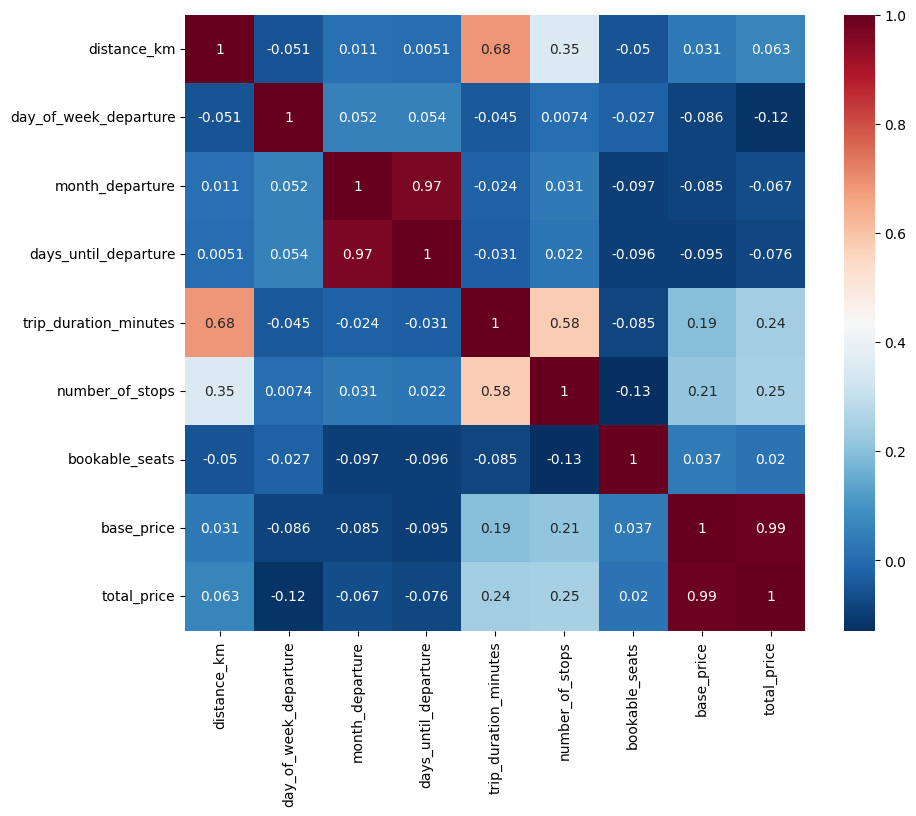

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
plt.show()

Observe categorical columns.

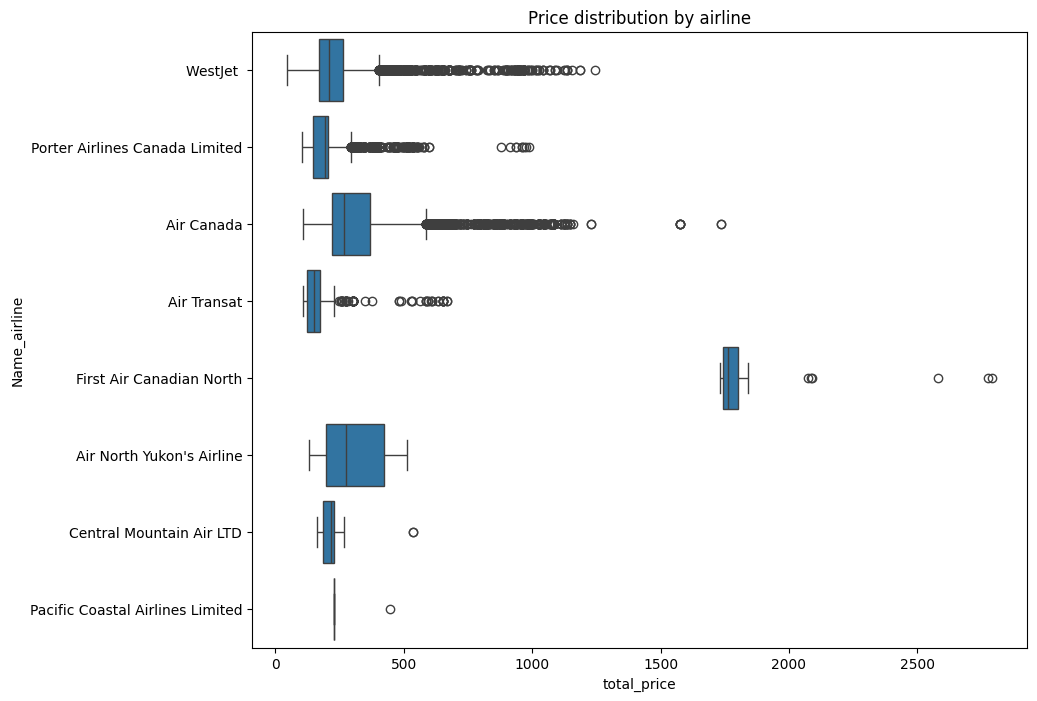

In [24]:
plt.figure(figsize=(10,8))
sns.boxplot(data = df, y = 'Name_airline', x = 'total_price')
plt.title('Price distribution by airline')
plt.show()

we can drop teh First Air Canadian North airline as it is an outlier and can skew predictions.

In [25]:
print(f'Number of flights for First Air Canadian North: {df[df["Name_airline"] == "First Air Canadian North"].shape[0]}')
df.groupby('Name_airline')['total_price'].mean().reset_index()

Number of flights for First Air Canadian North: 85


,Name_airline,total_price
0,Air Canada,311.336874
1,Air North Yukon's Airline,288.695190
2,Air Transat,180.814402
3,Central Mountain Air LTD,222.798596
4,First Air Canadian North,1809.866588
5,Pacific Coastal Airlines Limited,264.080000
6,Porter Airlines Canada Limited,199.675825
7,WestJet,225.006951


We can drop as it is < 2% of our dataset.

In [26]:
# drop rows with first air canadian north 
df.drop(df[df['Name_airline'] == 'First Air Canadian North'].index, inplace=True)

### 1. Price Distribution Analysis
Business Questions

- Which airline offers the lowest average price per route?
- Are there premium airlines on short routes?
- What is the typical price spread on a route?
- Are there pricing outliers that suggest premium or error fares?


In [27]:
# typcal price spread on a route
route_df = df.groupby(['origin','City','destination','City_destination'])['total_price'].mean().reset_index()
route_df['route'] = route_df['City'] + '-' + route_df['City_destination']

# airline offers the lowest average price
airline_price =df.groupby('Name_airline')['total_price'].mean().reset_index()

# airline offers the lowest average price per route
airline_route_price = df.groupby(['origin','City','destination','City_destination','Name_airline'])['total_price'].mean().reset_index()
airline_route_price['route'] = airline_route_price['City'] + '-' + airline_route_price['City_destination']

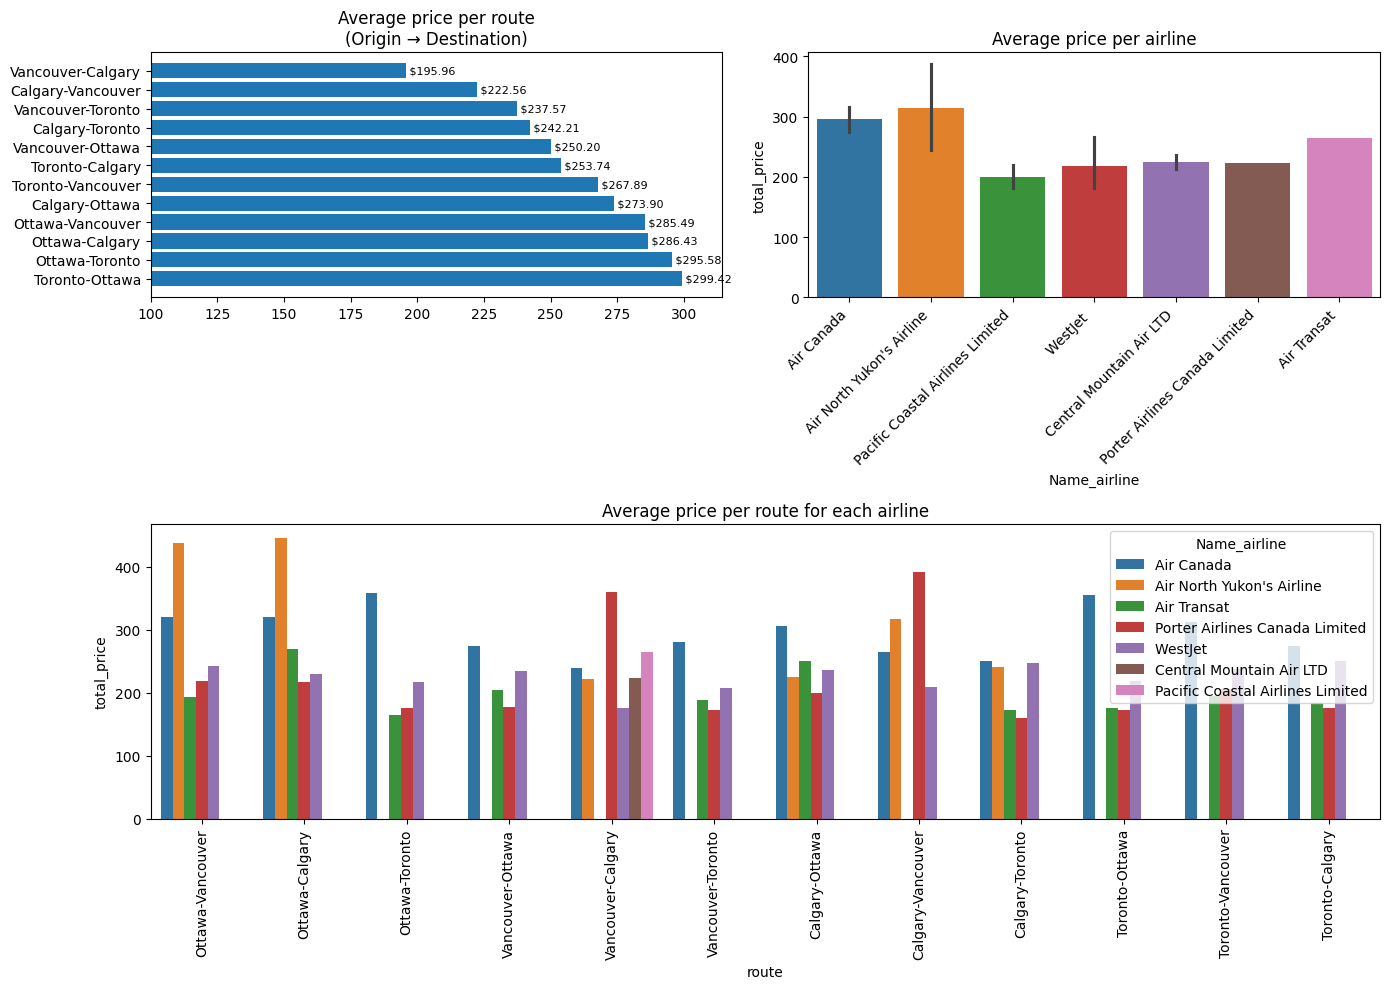

In [31]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.filterwarnings("ignore", category=UserWarning) 

route_sorted = route_df.sort_values('total_price', ascending=False)

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# Top-left: average price per route (horizontal bars)
ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(route_sorted['route'], route_sorted['total_price'])

for idx, val in enumerate(route_sorted['total_price']):
    ax1.text(val, idx, f' ${val:.2f}', ha='left', va='center', fontsize=8)

ax1.set_xlim(left = 100)
ax1.set_title('Average price per route\n(Origin → Destination)')

# Top-right: average price per airline
ax2 = fig.add_subplot(gs[0, 1])
airline_avg = df.groupby('Name_airline')['total_price'].mean().sort_values(ascending=False)
# ax2.bar(airline_avg.index, airline_avg.values)
sns.barplot(data=airline_route_price, x='Name_airline', y='total_price', hue='Name_airline', ax = ax2)
ax2.set_title('Average price per airline')
ax2.set_xticklabels(airline_avg.index, rotation=45, ha='right')

# Bottom (wide): average price per route for each airline
ax3 = fig.add_subplot(gs[1, :])
sns.barplot(
    data=airline_route_price,
    x='route',
    y='total_price',
    hue='Name_airline',
    ax=ax3
)
ax3.set_title('Average price per route for each airline')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

### 2. Price vs Days Until Departure (Very Important)
- How much does last-minute booking increase prices?
- Do prices increase as departure approaches (last-minute premium)?
- What is the optimal booking window for cheapest fares?
- Is there a "sweet spot" number of days ahead to buy?
- how many days till departure are prices the cheapest


In [38]:
# how many days to departure date is the lowest price?
# average price by days until departure - how in 10 days bins


df_days = df.groupby('days_until_departure')['total_price'].mean().reset_index()


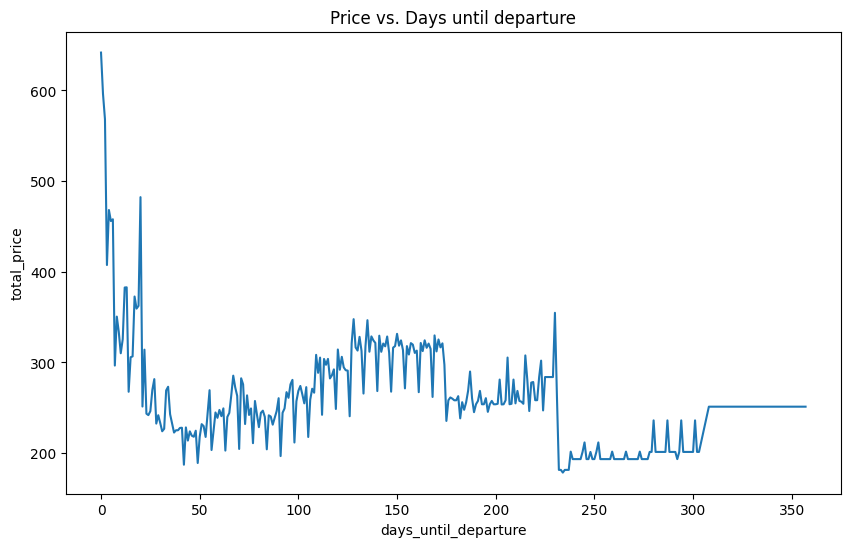

In [39]:
# show a line plot of average price by days until departure
plt.figure(figsize=(10,6))
sns.lineplot(data=df_days, x='days_until_departure', y='total_price')
plt.title('Price vs. Days until departure')
plt.show()

from the graph we can assume:
- prices are highest < 10 days until departure
- low price when you book 50 days till depature
- increase spike when we are 225 days till departure
- optimal window - good deal 40-120 days before departure

Text(0.5, 1.0, 'Price vs. Days until departure')

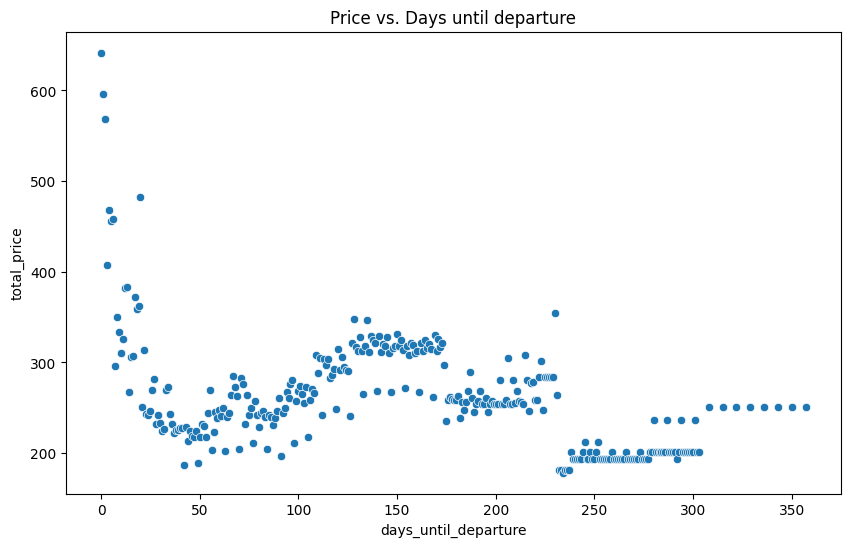

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_days, x='days_until_departure', y='total_price')
plt.title('Price vs. Days until departure')

### 3a. Price by Time of Year

### 3. Price by Day of Week
- Which days are cheapest to fly?
- Do airlines offer more flights on high-demand days?
- Is weekend travel priced higher than weekday on domestic routes?


In [59]:
# which day of the week are cheapest to fly
df['day_of_week_departure'] = df['day_of_week_departure'].map({0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'})
df.groupby('day_of_week_departure')['total_price'].agg(mean_price='mean', flight_count='count').reset_index()

,day_of_week_departure,mean_price,flight_count
0,Friday,289.791378,2706
1,Monday,289.635835,2588
2,Saturday,295.385892,2325
3,Sunday,250.088727,27869
4,Thursday,284.171505,2592
5,Tuesday,285.018229,2468
6,Wednesday,281.258367,2609


- Sundays are cheapest days to fly and have the most flights

In [61]:
# number fo flight offered by each airline by day of week
df.groupby(['Name_airline', 'day_of_week_departure'])['total_price'].count().reset_index()

,Name_airline,day_of_week_departure,total_price
0,Air Canada,Friday,1560
1,Air Canada,Monday,1458
2,Air Canada,Saturday,1556
3,Air Canada,Sunday,11013
4,Air Canada,Thursday,1516
5,Air Canada,Tuesday,1515
6,Air Canada,Wednesday,1558
7,Air North Yukon's Airline,Sunday,158
8,Air Transat,Friday,42
9,Air Transat,Monday,48


[Text(0, 0, 'Ottawa-Vancouver'),
 Text(1, 0, 'Ottawa-Calgary'),
 Text(2, 0, 'Ottawa-Toronto'),
 Text(3, 0, 'Vancouver-Ottawa'),
 Text(4, 0, 'Vancouver-Calgary'),
 Text(5, 0, 'Vancouver-Toronto'),
 Text(6, 0, 'Calgary-Ottawa'),
 Text(7, 0, 'Calgary-Vancouver'),
 Text(8, 0, 'Calgary-Toronto'),
 Text(9, 0, 'Toronto-Ottawa'),
 Text(10, 0, 'Toronto-Vancouver'),
 Text(11, 0, 'Toronto-Calgary')]

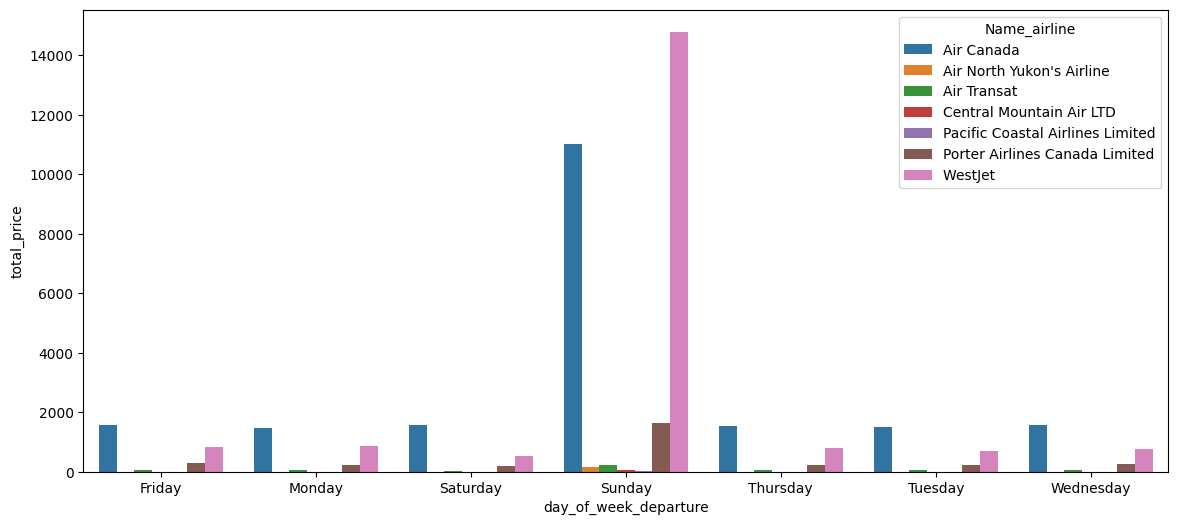

In [63]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df.groupby(['Name_airline', 'day_of_week_departure'])['total_price'].count().reset_index(),
    hue='Name_airline',
    y='total_price',
    x='day_of_week_departure',
)
ax3.set_title('Average price per route for each airline')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=90)

### 4. Price by Time of Day
- Are early morning or red-eye flights cheaper?
- Which departure windows are most expensive (peak demand times)?
- Do airlines price differently for business-hour vs. off-peak flights?


### 5. Airline Pricing Strategy
- Which airline is cheapest on the same route?
- Do budget carriers (PD = Porter) consistently undercut legacy carriers (AC = Air Canada)?
- Is there a price-seat availability tradeoff — do cheaper flights have fewer seats left?


### 6. Aircraft Type Analysis
- Do certain aircraft (e.g., regional jets vs. mainline) command price differences?
- Are newer/larger aircraft associated with more bookable seats and lower per-seat pricing?


### 7. Flight Duration vs Price
- Do longer flights cost more?
- Are there fast premium flights?

### 8. Stops vs Price
- How much cheaper are connecting flights vs direct flights?
- Are connecting flights cheaper than direct on the same route?
- At what price difference would a traveler prefer a layover?
- Do stops correlate with specific airlines or aircraft types?


### 9. Route-Level Analysis
- Which routes are most expensive per minute of travel?
- Which routes have high competition?
- Which routes have the most airline competition, and does competition lower prices?
- Are longer routes priced proportionally, or do short routes have disproportionate fares?
- Which origin-destination pairs have the least seat availability (capacity-constrained routes)?



### 9. Price Components Analysis
- Which airlines add higher fees?
- How much of ticket cost is base fare vs taxes?
